# Supplementary — sigmoidal and polynomial stiffness

F vs d and K vs d for non-linear displacement-dependent stiffness profiles
(sigmoid and polynomial K(d)) applied via a task-space DIP spring.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, ast
from glob import glob

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)

plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']


def _read_constant(filepath, name):
    """Extract a numeric constant from a Python file without importing it."""
    tree = ast.parse(open(filepath, encoding='utf-8').read())
    for node in ast.walk(tree):
        if (isinstance(node, ast.Assign)
                and any(isinstance(t, ast.Name) and t.id == name for t in node.targets)):
            return ast.literal_eval(node.value)
    raise KeyError(f'{name} not found in {filepath}')


_SP = os.path.join('sigmoidal_polynomial_stiffness.py')
K_MIN  = _read_constant(_SP, 'K_MIN')
K_MAX  = _read_constant(_SP, 'K_MAX')
D_TH   = _read_constant(_SP, 'D_TH')
D_NORM = _read_constant(_SP, 'D_NORM')
print(f'K_MIN={K_MIN}  K_MAX={K_MAX}  D_TH={D_TH}  D_NORM={D_NORM}  (from sigmoidal_polynomial_stiffness.py)')


def available_params(mode):
    output_dir = os.path.join('outputs', f'{mode}_stiffness')
    prefix = 'alpha_' if mode == 'sigmoid' else 'order_'
    vals = []
    for folder in glob(os.path.join(output_dir, f'{prefix}*')):
        name = os.path.basename(folder)
        try:
            vals.append(float(name.split('_', 1)[1]))
        except ValueError:
            pass
    return sorted(vals)


MODES = {
    'sigmoid': {
        'sweep':       available_params('sigmoid'),
        'output_dir':  os.path.join('outputs', 'sigmoid_stiffness'),
        'param_label': lambda p: f'alpha_{p:g}',
        'param_latex': lambda p: rf'$\alpha = {p:g}$ m$^{{-1}}$',
        'vline_val':   D_TH,
        'vline_label': rf'$d_{{th}} = {int(D_TH*1e3)}$ mm',
        'hlines':      [(K_MIN, ':',  rf'$K_{{\min}} = {K_MIN}$'),
                        (K_MAX, '--', rf'$K_{{\max}} = {K_MAX}$')],
    },
    'polynomial': {
        'sweep':       available_params('polynomial'),
        'output_dir':  os.path.join('outputs', 'polynomial_stiffness'),
        'param_label': lambda p: f'order_{int(p) if float(p).is_integer() else p:g}',
        'param_latex': lambda p: rf'$n = {int(p) if float(p).is_integer() else p:g}$',
        'vline_val':   D_NORM,
        'vline_label': rf'$d_{{norm}} = {int(D_NORM*1e3)}$ mm',
        'hlines':      [(K_MIN, ':',  rf'$K_{{\min}} = {K_MIN}$')],
    },
}


def load_runs(cfg, p):
    lbl = cfg['param_label'](p)
    pattern = os.path.join(cfg['output_dir'], lbl, f'{lbl}_run_*.csv')
    return [pd.read_csv(f) for f in sorted(glob(pattern))]


def select_phase(df, phase='descent'):
    if 'Phase' not in df.columns:
        return df
    dff = df[df['Phase'] == phase].copy()
    if dff.empty:
        return df
    return dff


def interp_disp(dfs, col, n_pts=500, phase='descent'):
    phase_dfs = [select_phase(df, phase).sort_values('UR5_displacement_m') for df in dfs]
    d_max = min(0.02, min(df['UR5_displacement_m'].max() for df in phase_dfs))
    d = np.linspace(0, d_max, n_pts)
    vals = np.array([np.interp(d, df['UR5_displacement_m'], df[col]) for df in phase_dfs])
    return d, vals


data = {mode: {p: load_runs(cfg, p) for p in cfg['sweep']}
        for mode, cfg in MODES.items()}

for mode, cfg in MODES.items():
    for p in cfg['sweep']:
        print(f'{mode}  {cfg["param_label"](p)}  ->  {len(data[mode][p])} run(s)')

K_MIN=10.0  K_MAX=100.0  D_TH=0.01  D_NORM=0.01  (from sigmoidal_polynomial_stiffness.py)
sigmoid  alpha_0  ->  5 run(s)
sigmoid  alpha_100  ->  5 run(s)
sigmoid  alpha_1000  ->  5 run(s)
polynomial  order_0  ->  5 run(s)
polynomial  order_1  ->  5 run(s)
polynomial  order_2  ->  5 run(s)


## Sigmoid – F vs d

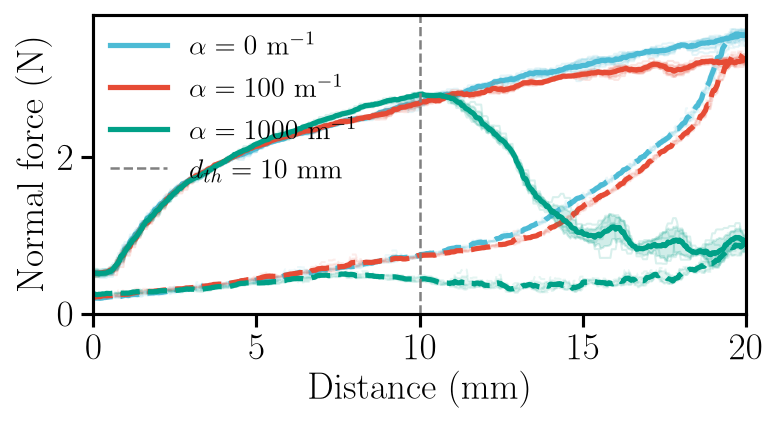

In [4]:
mode, cfg = 'sigmoid', MODES['sigmoid']
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

phase_specs = [
    ('descent', '-',  0.15, 0.18),
    ('ascent',  '--', 0.10, 0.10),
]

for idx, p in enumerate(cfg['sweep']):
    runs = data[mode][p]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        d, vals = interp_disp(runs, 'Force_N', phase=phase)
        d_mm = d * 1e3
        mean, std = vals.mean(0), vals.std(0)
        for v in vals:
            ax.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                label=cfg['param_latex'](p) if phase == 'descent' else None)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)

ax.axvline(cfg['vline_val'] * 1e3, color='gray', linestyle='--',
           linewidth=1.2, label=cfg['vline_label'])
ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Normal force (N)')
ax.legend(loc='upper left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
os.makedirs(cfg['output_dir'], exist_ok=True)
fig.savefig(os.path.join(cfg['output_dir'], 'F_vs_d.pdf'))
plt.show()

## Sigmoid – K vs d

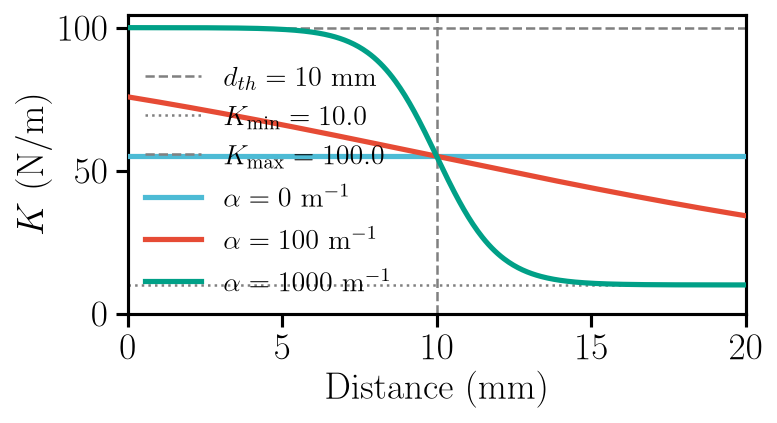

In [5]:
# ---- Sigmoid stiffness as a function of displacement (model law) ----
# K(d) = K_max - (K_max - K_min) / (1 + exp(-alpha*(d - D_TH)))   (sigmoidal_polynomial_stiffness.py)
mode, cfg = 'sigmoid', MODES['sigmoid']
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

# Whole displacement range (UR5 press depth)
d    = np.linspace(0.0, 0.020, 400)   # [m]
d_mm = d * 1e3


def sigmoid_k(alpha, dd):
    """K(d) = K_max - (K_max - K_min) / (1 + exp(-alpha*(d - D_TH)))."""
    return K_MAX - (K_MAX - K_MIN) / (1.0 + np.exp(-alpha * (dd - D_TH)))


# Reference lines first (zorder low) so the law curves always stay visible on top
ax.axvline(cfg['vline_val'] * 1e3, color='gray', linestyle='--',
           linewidth=1.2, label=cfg['vline_label'], zorder=1)
for val, ls, lbl in cfg['hlines']:
    ax.axhline(val, color='gray', linestyle=ls, linewidth=1.2, label=lbl, zorder=1)

for idx, p in enumerate(cfg['sweep']):
    color = COLORS[idx % len(COLORS)]
    ax.plot(d_mm, sigmoid_k(p, d), color=color, linewidth=2.5,
            label=cfg['param_latex'](p), zorder=3)

ax.set_xlabel('Distance (mm)')
ax.set_ylabel(r'$K$ (N/m)')
ax.legend(loc='lower left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(os.path.join(cfg['output_dir'], 'K_vs_d.pdf'))
plt.show()

## Polynomial – F vs d

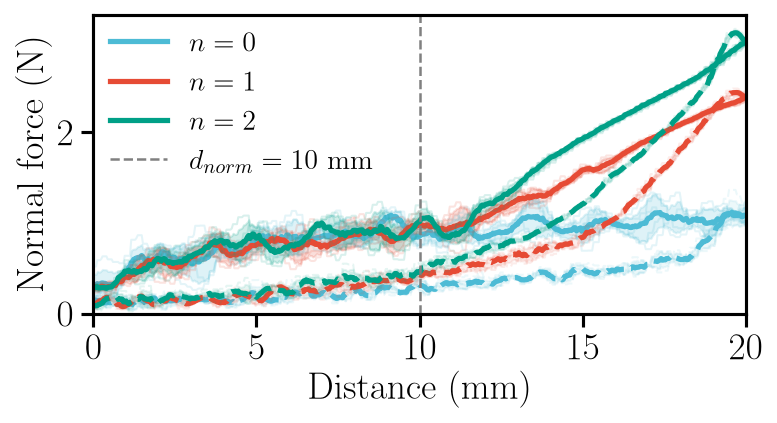

In [6]:
mode, cfg = 'polynomial', MODES['polynomial']
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

phase_specs = [
    ('descent', '-',  0.15, 0.18),
    ('ascent',  '--', 0.10, 0.10),
]

for idx, p in enumerate(cfg['sweep']):
    runs = data[mode][p]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        d, vals = interp_disp(runs, 'Force_N', phase=phase)
        d_mm = d * 1e3
        mean, std = vals.mean(0), vals.std(0)
        for v in vals:
            ax.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                label=cfg['param_latex'](p) if phase == 'descent' else None)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)

ax.axvline(cfg['vline_val'] * 1e3, color='gray', linestyle='--',
           linewidth=1.2, label=cfg['vline_label'])
ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Normal force (N)')
ax.legend(loc='upper left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
os.makedirs(cfg['output_dir'], exist_ok=True)
fig.savefig(os.path.join(cfg['output_dir'], 'F_vs_d.pdf'))
plt.show()

## Polynomial – K vs d

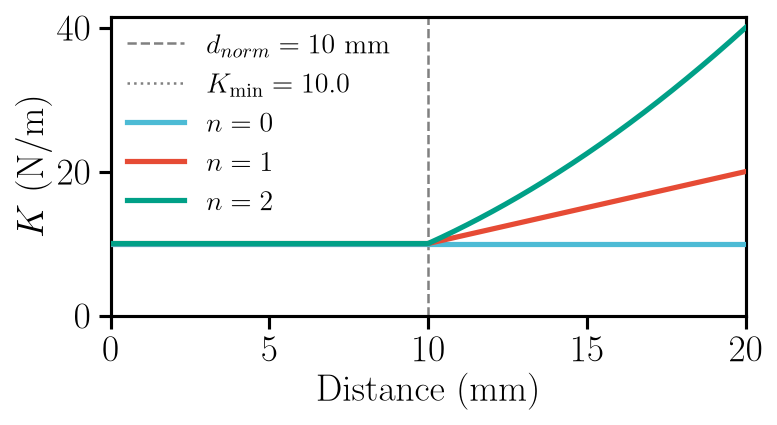

In [7]:
# ---- Polynomial stiffness as a function of displacement (model law) ----
# K(d) = max(K_min, K_base * (d / D_NORM)^n)   (sigmoidal_polynomial_stiffness.py)
mode, cfg = 'polynomial', MODES['polynomial']
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

# Whole displacement range (UR5 press depth)
d    = np.linspace(0.0, 0.020, 400)   # [m]
d_mm = d * 1e3

K_BASE = K_MIN   # polynomial stiffness at d = D_NORM (K_BASE = K_MIN in the .py)


def polynomial_k(order, dd):
    """K(d) = max(K_min, K_base * (d/D_NORM)^order)."""
    return np.maximum(K_MIN, K_BASE * (np.maximum(dd, 0.0) / D_NORM) ** order)


# Reference lines first (zorder low) so the law curves always stay visible on top
ax.axvline(cfg['vline_val'] * 1e3, color='gray', linestyle='--',
           linewidth=1.2, label=cfg['vline_label'], zorder=1)
for val, ls, lbl in cfg['hlines']:
    ax.axhline(val, color='gray', linestyle=ls, linewidth=1.2, label=lbl, zorder=1)

for idx, p in enumerate(cfg['sweep']):
    color = COLORS[idx % len(COLORS)]
    ax.plot(d_mm, polynomial_k(p, d), color=color, linewidth=2.5,
            label=cfg['param_latex'](p), zorder=3)

ax.set_xlabel('Distance (mm)')
ax.set_ylabel(r'$K$ (N/m)')
ax.legend(loc='upper left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(os.path.join(cfg['output_dir'], 'K_vs_d.pdf'))
plt.show()